In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from src.custom_fastkan import FastKAN
import pandas as pd
import torch.nn.functional as F

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


X_train_full = torch.tensor(train_dataset.data).float().reshape(-1, 3072) / 255.0
X_train_full = X_train_full * 2 - 1
y_train_full = torch.tensor(train_dataset.targets)

X_test = torch.tensor(test_dataset.data).float().reshape(-1, 3072) / 255.0
X_test = X_test * 2 - 1
y_test = torch.tensor(test_dataset.targets)

torch.manual_seed(42)
indices = torch.randperm(len(X_train_full))
val_size = 10000
train_size = len(X_train_full) - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train = X_train_full[train_indices].to(device)
y_train = y_train_full[train_indices].to(device)

X_val = X_train_full[val_indices].to(device)
y_val = y_train_full[val_indices].to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
print(f"Classes: {len(torch.unique(y_train))}")

100%|██████████| 170498071/170498071 [00:18<00:00, 9041215.34it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Train shape: torch.Size([40000, 3072]), Val shape: torch.Size([10000, 3072]), Test shape: torch.Size([10000, 3072])
Classes: 10


In [3]:
model = FastKAN([3072, 256, 10], grid_min=-1.2, grid_max=1.2, num_grids=8, use_base_update=True, use_layernorm=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

In [4]:
print("Training KAN...")
train_losses = []
val_losses = []
train_accs = []
val_accs = []

batch_size = 256
num_batches = len(X_train) // batch_size

for epoch in range(25): 
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    indices = torch.randperm(len(X_train))
    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(pred.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_acc = 100 * correct / total
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
        _, val_predicted = torch.max(val_pred.data, 1)
        val_acc = 100 * (val_predicted == y_val).sum().item() / len(y_val)
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test).item()
    _, test_predicted = torch.max(test_pred.data, 1)
    test_acc = 100 * (test_predicted == y_test).sum().item() / len(y_test)
    
    print(f"\nKAN Test Loss: {test_loss:.4f}")
    print(f"KAN Test Accuracy: {test_acc:.2f}%")

Training KAN...
Epoch 0, Train Loss: 2.2354, Train Acc: 32.04%, Val Loss: 1.7749, Val Acc: 39.75%
Epoch 1, Train Loss: 1.4701, Train Acc: 49.34%, Val Loss: 1.6214, Val Acc: 44.73%
Epoch 2, Train Loss: 1.1274, Train Acc: 61.67%, Val Loss: 1.6128, Val Acc: 46.37%
Epoch 3, Train Loss: 0.8928, Train Acc: 70.55%, Val Loss: 1.6055, Val Acc: 47.67%
Epoch 4, Train Loss: 0.7239, Train Acc: 77.05%, Val Loss: 1.6853, Val Acc: 45.98%
Epoch 5, Train Loss: 0.5994, Train Acc: 81.33%, Val Loss: 1.7247, Val Acc: 45.33%
Epoch 6, Train Loss: 0.5524, Train Acc: 82.39%, Val Loss: 1.7974, Val Acc: 45.35%
Epoch 7, Train Loss: 0.5025, Train Acc: 83.97%, Val Loss: 1.8896, Val Acc: 45.26%
Epoch 8, Train Loss: 0.4786, Train Acc: 84.39%, Val Loss: 1.8915, Val Acc: 45.34%
Epoch 9, Train Loss: 0.4199, Train Acc: 86.35%, Val Loss: 1.9068, Val Acc: 46.36%
Epoch 10, Train Loss: 0.3431, Train Acc: 89.18%, Val Loss: 2.0149, Val Acc: 45.53%
Epoch 11, Train Loss: 0.3082, Train Acc: 90.44%, Val Loss: 2.0288, Val Acc: 46.96


Analyzing individual KAN prediction losses...

KAN Loss Statistics:
Mean Loss: 2.866281
Min Loss: -0.000000
Max Loss: 22.818785


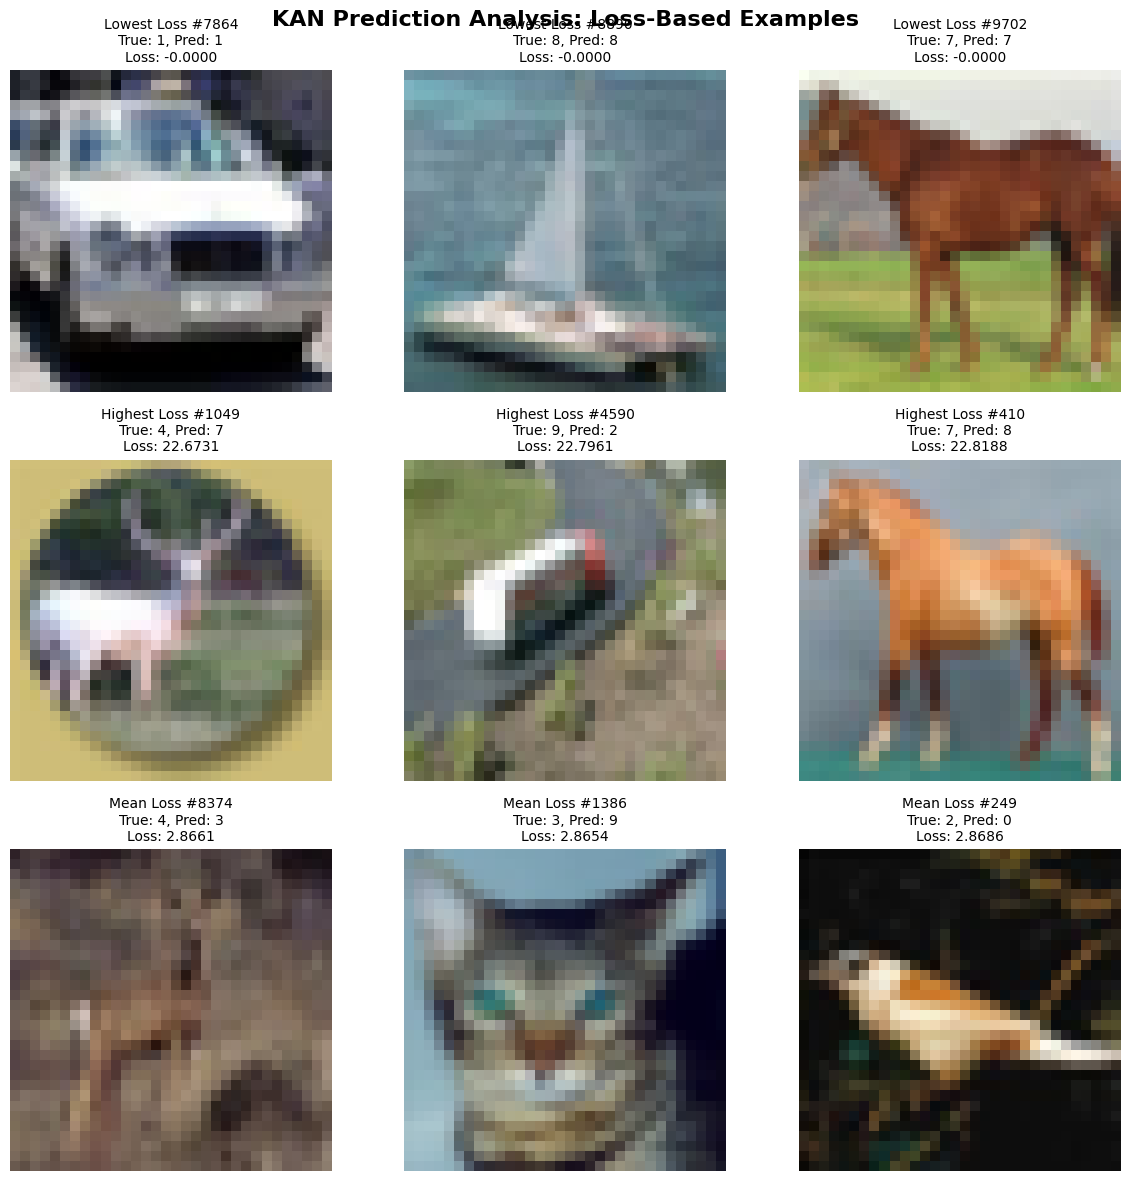

In [5]:
def plot_cifar_prediction(input_img, ground_truth, prediction, probs, example_idx, loss_val, category, ax):
    img = input_img.reshape(32, 32, 3).cpu().numpy()
    img = (img + 1) / 2
    
    ax.imshow(img)
    ax.set_title(f'{category} #{example_idx}\nTrue: {ground_truth}, Pred: {prediction}\nLoss: {loss_val:.4f}', fontsize=10)
    ax.axis('off')

print("\nAnalyzing individual KAN prediction losses...")
individual_losses = []
predictions = []
probabilities = []

with torch.no_grad():
    logits = model(X_test)
    loss_per_sample = F.cross_entropy(logits, y_test, reduction='none')
    probs = F.softmax(logits, dim=1)
    _, preds = torch.max(logits, 1)
    
    individual_losses = loss_per_sample.cpu().numpy()
    predictions = preds.cpu().numpy()
    probabilities = probs.cpu().numpy()

sorted_indices = np.argsort(individual_losses)

mean_loss = np.mean(individual_losses)
lowest_indices = sorted_indices[:3] 
highest_indices = sorted_indices[-3:]

mean_distances = np.abs(individual_losses - mean_loss)
mean_sorted_indices = np.argsort(mean_distances)
mean_indices = mean_sorted_indices[:3]

print(f"\nKAN Loss Statistics:")
print(f"Mean Loss: {mean_loss:.6f}")
print(f"Min Loss: {individual_losses[lowest_indices[0]]:.6f}")
print(f"Max Loss: {individual_losses[highest_indices[-1]]:.6f}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('KAN Prediction Analysis: Loss-Based Examples', fontsize=16, fontweight='bold')

for i, idx in enumerate(lowest_indices):
    plot_cifar_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Lowest Loss", axes[0, i]
    )
for i, idx in enumerate(highest_indices):
    plot_cifar_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Highest Loss", axes[1, i]
    )
for i, idx in enumerate(mean_indices):
    plot_cifar_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Mean Loss", axes[2, i]
    )
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [6]:
import torch.nn as nn
torch.manual_seed(42)

class MLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dims=[256, 256], output_dim=10):
        super(MLP, self).__init__()
        layers = []
        curr_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, output_dim))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

mlp_model = MLP(input_dim=3072, hidden_dims=[256, 256], output_dim=10).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

print("Training MLP...")
mlp_train_losses = []
mlp_val_losses = []
mlp_train_accs = []
mlp_val_accs = []

batch_size = 256

for epoch in range(25):
    mlp_model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    indices = torch.randperm(len(X_train))
    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        mlp_optimizer.zero_grad()
        pred = mlp_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        mlp_optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(pred.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_acc = 100 * correct / total
    
    mlp_model.eval()
    with torch.no_grad():
        val_pred = mlp_model(X_val)
        val_loss = criterion(val_pred, y_val).item()
        _, val_predicted = torch.max(val_pred.data, 1)
        val_acc = 100 * (val_predicted == y_val).sum().item() / len(y_val)
    
    mlp_train_losses.append(avg_train_loss)
    mlp_val_losses.append(val_loss)
    mlp_train_accs.append(train_acc)
    mlp_val_accs.append(val_acc)
    
    print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

mlp_model.eval()
with torch.no_grad():
    mlp_test_pred = mlp_model(X_test)
    mlp_test_loss = criterion(mlp_test_pred, y_test).item()
    _, mlp_test_predicted = torch.max(mlp_test_pred.data, 1)
    mlp_test_acc = 100 * (mlp_test_predicted == y_test).sum().item() / len(y_test)
    
    print(f"\nMLP Test Loss: {mlp_test_loss:.4f}")
    print(f"MLP Test Accuracy: {mlp_test_acc:.2f}%")

Training MLP...
Epoch 0, Train Loss: 1.6906, Train Acc: 40.12%, Val Loss: 1.5776, Val Acc: 44.04%
Epoch 1, Train Loss: 1.4635, Train Acc: 48.63%, Val Loss: 1.4717, Val Acc: 48.50%
Epoch 2, Train Loss: 1.3534, Train Acc: 52.55%, Val Loss: 1.4017, Val Acc: 51.50%
Epoch 3, Train Loss: 1.2511, Train Acc: 56.21%, Val Loss: 1.3758, Val Acc: 52.07%
Epoch 4, Train Loss: 1.1745, Train Acc: 58.98%, Val Loss: 1.3623, Val Acc: 52.20%
Epoch 5, Train Loss: 1.1010, Train Acc: 61.51%, Val Loss: 1.3529, Val Acc: 53.37%
Epoch 6, Train Loss: 1.0210, Train Acc: 64.31%, Val Loss: 1.3899, Val Acc: 51.99%
Epoch 7, Train Loss: 0.9507, Train Acc: 66.68%, Val Loss: 1.4219, Val Acc: 52.71%
Epoch 8, Train Loss: 0.8816, Train Acc: 69.23%, Val Loss: 1.4493, Val Acc: 53.01%
Epoch 9, Train Loss: 0.8288, Train Acc: 71.34%, Val Loss: 1.4230, Val Acc: 53.31%
Epoch 10, Train Loss: 0.7579, Train Acc: 73.73%, Val Loss: 1.4770, Val Acc: 53.49%
Epoch 11, Train Loss: 0.6840, Train Acc: 76.34%, Val Loss: 1.5980, Val Acc: 52.49

In [7]:
from sklearn.metrics import r2_score, mean_squared_error

def calculate_metrics(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = F.softmax(logits, dim=1)
        
        # One-hot encode targets
        y_onehot = F.one_hot(y, num_classes=10).float()
        
        # Move to CPU for sklearn
        probs_np = probs.cpu().numpy()
        y_onehot_np = y_onehot.cpu().numpy()
        
        # Calculate MSE
        mse = mean_squared_error(y_onehot_np, probs_np)
        
        # Calculate R2 (average over all output dimensions)
        r2 = r2_score(y_onehot_np, probs_np)
        
        return mse, r2

kan_mse, kan_r2 = calculate_metrics(model, X_test, y_test)
mlp_mse, mlp_r2 = calculate_metrics(mlp_model, X_test, y_test)

print(f"KAN Test MSE: {kan_mse:.6f}, R2: {kan_r2:.6f}")
print(f"MLP Test MSE: {mlp_mse:.6f}, R2: {mlp_r2:.6f}")

KAN Test MSE: 0.086443, R2: 0.039577
MLP Test MSE: 0.078138, R2: 0.131848



Analyzing individual MLP prediction losses...

MLP Loss Statistics:
Mean Loss: 2.724543
Min Loss: -0.000000
Max Loss: 43.324841


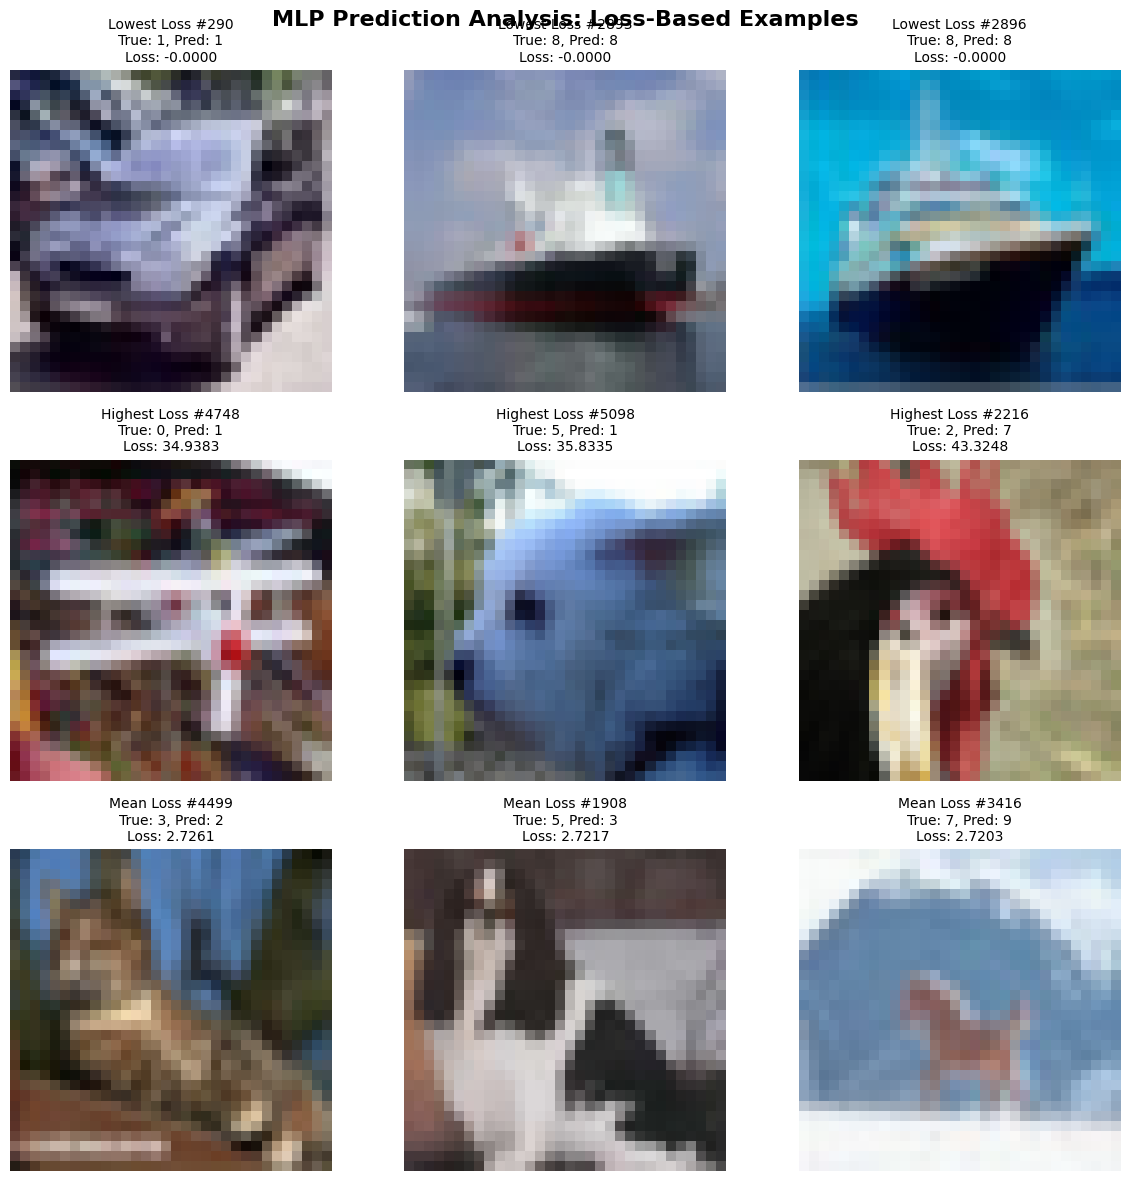

In [8]:
print("\nAnalyzing individual MLP prediction losses...")
mlp_individual_losses = []
mlp_predictions = []
mlp_probabilities = []

with torch.no_grad():
    logits = mlp_model(X_test)
    loss_per_sample = F.cross_entropy(logits, y_test, reduction='none')
    probs = F.softmax(logits, dim=1)
    _, preds = torch.max(logits, 1)
    
    mlp_individual_losses = loss_per_sample.cpu().numpy()
    mlp_predictions = preds.cpu().numpy()
    mlp_probabilities = probs.cpu().numpy()

mlp_sorted_indices = np.argsort(mlp_individual_losses)

mlp_mean_loss = np.mean(mlp_individual_losses)
mlp_lowest_indices = mlp_sorted_indices[:3] 
mlp_highest_indices = mlp_sorted_indices[-3:]

mlp_mean_distances = np.abs(mlp_individual_losses - mlp_mean_loss)
mlp_mean_sorted_indices = np.argsort(mlp_mean_distances)
mlp_mean_indices = mlp_mean_sorted_indices[:3]

print(f"\nMLP Loss Statistics:")
print(f"Mean Loss: {mlp_mean_loss:.6f}")
print(f"Min Loss: {mlp_individual_losses[mlp_lowest_indices[0]]:.6f}")
print(f"Max Loss: {mlp_individual_losses[mlp_highest_indices[-1]]:.6f}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('MLP Prediction Analysis: Loss-Based Examples', fontsize=16, fontweight='bold')

for i, idx in enumerate(mlp_lowest_indices):
    plot_cifar_prediction(
        X_test[idx], y_test[idx].item(), mlp_predictions[idx], mlp_probabilities[idx],
        idx, mlp_individual_losses[idx], "Lowest Loss", axes[0, i]
    )
for i, idx in enumerate(mlp_highest_indices):
    plot_cifar_prediction(
        X_test[idx], y_test[idx].item(), mlp_predictions[idx], mlp_probabilities[idx],
        idx, mlp_individual_losses[idx], "Highest Loss", axes[1, i]
    )
for i, idx in enumerate(mlp_mean_indices):
    plot_cifar_prediction(
        X_test[idx], y_test[idx].item(), mlp_predictions[idx], mlp_probabilities[idx],
        idx, mlp_individual_losses[idx], "Mean Loss", axes[2, i]
    )
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [9]:
table_data = []
categories = [("Lowest", lowest_indices), ("Highest", highest_indices), ("Mean", mean_indices)]

for label, indices in categories:
    for idx in indices:
        table_data.append({
            "Category": label,
            "Index": idx,
            "True Label": y_test[idx].item(),
            "Predicted Label": predictions[idx].item(),
            "Confidence": f"{probabilities[idx][predictions[idx]]:.4f}",
            "Loss": individual_losses[idx]
        })

df_kan_analysis = pd.DataFrame(table_data)
df_kan_analysis

,Category,Index,True Label,Predicted Label,Confidence,Loss
0,Lowest,7864,1,1,1.0000,-0.000000
1,Lowest,8890,8,8,1.0000,-0.000000
2,Lowest,9702,7,7,1.0000,-0.000000
3,Highest,1049,4,7,1.0000,22.673143
4,Highest,4590,9,2,0.9999,22.796129
5,Highest,410,7,8,1.0000,22.818785
6,Mean,8374,4,3,0.8138,2.866059
7,Mean,1386,3,9,0.6263,2.865376
8,Mean,249,2,0,0.5255,2.868633


In [10]:
table_data_mlp = []
categories = [("Lowest", mlp_lowest_indices), ("Highest", mlp_highest_indices), ("Mean", mlp_mean_indices)]

for label, indices in categories:
    for idx in indices:
        table_data_mlp.append({
            "Category": label,
            "Index": idx,
            "True Label": y_test[idx].item(),
            "Predicted Label": mlp_predictions[idx].item(),
            "Confidence": f"{mlp_probabilities[idx][mlp_predictions[idx]]:.4f}",
            "Loss": mlp_individual_losses[idx]
        })

df_mlp_analysis = pd.DataFrame(table_data_mlp)
df_mlp_analysis

,Category,Index,True Label,Predicted Label,Confidence,Loss
0,Lowest,290,1,1,1.0000,-0.000000
1,Lowest,2893,8,8,1.0000,-0.000000
2,Lowest,2896,8,8,1.0000,-0.000000
3,Highest,4748,0,1,1.0000,34.938278
4,Highest,5098,5,1,0.9924,35.833488
5,Highest,2216,2,7,1.0000,43.324841
6,Mean,4499,3,2,0.4443,2.726070
7,Mean,1908,5,3,0.8656,2.721694
8,Mean,3416,7,9,0.7494,2.720273


In [11]:
mlp_save_path = "model_pkls/cifar_mlp_model.pkl"
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'config': {
        'input_dim': 3072,
        'hidden_dims': [256, 256],
        'output_dim': 10
    }
}, mlp_save_path)
print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to model_pkls/cifar_mlp_model.pkl


In [12]:
kan_save_path = "model_pkls/cifar_kan_model.pkl"
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'layers_hidden': [3072, 64, 10],
        'grid_min': -1.2,
        'grid_max': 1.2,
        'num_grids': 5,
        'use_base_update': False,
        'use_layernorm': False,
    }
}, kan_save_path)
print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to model_pkls/cifar_kan_model.pkl
